# DFS & BFS

## Problem Class Overview

The `Problem` class defines the abstract structure of a search problem within an intelligent agent framework.  
It provides the essential components needed for algorithms such as BFS, DFS, Uniform Cost Search, A*, and others.

### Key Responsibilities

- **Define the initial state** from which the search begins.
- **Specify the goal state** the agent is trying to reach.
- **Expose the set of valid actions** available from any given state.
- **Describe the transition model**, i.e., how actions transform one state into another.
- **Evaluate whether a state satisfies the goal condition.**
- **Provide a cost function** for actions, enabling cost‑based search algorithms.

### Class Structure

- `__init__(initial, goal)`  
  Stores the initial and goal states of the problem.

- `actions(state)`  
  Must be implemented by subclasses.  
  Returns the list of possible actions that can be taken from the given state.

- `result(state, action)`  
  Must be implemented by subclasses.  
  Defines the state that results from applying an action to the current state.

- `is_goal(state)`  
  Returns `True` if the given state matches the goal state.

- `action_cost(state1, action, state2)`  
  Returns the cost of performing the action that moves the agent from `state1` to `state2`.  
  The default implementation assigns a uniform cost of `1`.

### Usage

This class serves as the foundation for building specific search problems.  
To use it, create a subclass that implements `actions` and `result`, and then pass an instance of that subclass to a search algorithm.


In [1]:
class Problem:
    def __init__(self, initial, goal):
        self.initial = initial#Estado inicial
        self.goal = goal#Meta

    def actions(self):
        raise NotImplementedError

    def result(self, state, action):
        raise NotImplementedError

    # Función de desempeño
    def is_goal(self, state):
        return self.goal == state

    def action_cost(self, state1, action, state2):
        return 1
    

## GraphProblem Class Overview

The `GraphProblem` class is a concrete specialization of the abstract `Problem` class.  
It models search problems where states are nodes in a graph and actions correspond to moving along edges.  
This structure is ideal for path‑finding tasks such as navigating transportation networks, maps, or any domain represented as a graph.

### Key Responsibilities

- **Store the graph structure** used by the search algorithm.
- **Expose valid actions** from a given state based on graph connectivity.
- **Define the transition model**, where each action leads directly to the neighboring node.
- **Provide a cost function** derived from the graph’s edge weights.

### Class Structure

- `__init__(initial, goal, graph)`  
  Initializes the problem with:
  - an initial state,
  - a goal state,
  - a graph represented as a dictionary of dictionaries  
    (e.g., `graph[state][neighbor] = cost`).

- `actions(state)`  
  Returns the list of all neighboring nodes directly reachable from the given state.  
  These neighbors correspond to the keys inside `graph[state]`.

- `result(state, action)`  
  Defines the transition model.  
  Since each action is simply the name of a neighboring node, the resulting state is the action itself.

- `action_cost(state1, action, state2)`  
  Returns the cost of moving from `state1` to `state2`.  
  The cost is retrieved directly from the graph’s edge weight:  
  `graph[state1][state2]`.

### Usage

This class is designed for search algorithms such as BFS, DFS, Uniform Cost Search, A*, and Dijkstra.  
By providing a graph‑based representation of the environment, it allows the agent to compute optimal or feasible paths between nodes.


In [2]:
class GraphProblem(Problem):
    def __init__(self, initial, goal, graph):
        super().__init__(initial, goal)
        self.graph = graph

    def actions(self, state):
        return [key for key in self.graph[state].keys()]

    #Funcion de transición
    def result(self,state, action):
        return action

    def action_cost(self, state1, action, state2):
        return self.graph[state1][state2]

## First Example

Romania station's network

In [3]:
romania = {
    'Arad': {'Zerind': 75, 'Sibiu': 140, 'Timisoara': 118},
    'Zerind': {'Arad': 75, 'Oradea': 71},
    'Oradea': {'Zerind': 71, 'Sibiu': 151},
    'Sibiu': {'Arad': 140, 'Oradea': 151, 'Fagaras': 99, 'Rimnicu Vilcea': 80},
    'Timisoara': {'Arad': 118, 'Lugoj': 111},
    'Lugoj': {'Timisoara': 111, 'Mehadia': 70},
    'Mehadia': {'Lugoj': 70, 'Dobreta': 75},
    'Dobreta': {'Mehadia': 75, 'Craiova': 120},
    'Craiova': {'Dobreta': 120, 'Rimnicu Vilcea': 146, 'Pitesti': 138},
    'Rimnicu Vilcea': {'Sibiu': 80, 'Craiova': 146, 'Pitesti': 97},
    'Fagaras': {'Sibiu': 99, 'Bucarest': 211},
    'Pitesti': {'Rimnicu Vilcea': 97, 'Craiova': 138, 'Bucarest': 101},
    'Bucarest': {'Fagaras': 211, 'Pitesti': 101, 'Giurgiu': 90, 'Urziceni': 85},
    'Giurgiu': {'Bucarest': 90},
    'Urziceni': {'Bucarest': 85, 'Hirsova': 98, 'Vaslui': 142},
    'Hirsova': {'Urziceni': 98, 'Eforie': 86},
    'Eforie': {'Hirsova': 86},
    'Vaslui': {'Urziceni': 142, 'Iasi': 92},
    'Iasi': {'Vaslui': 92, 'Neamt': 87},
    'Neamt': {'Iasi': 87},
}

## Node Class Overview

The `Node` class represents a single node in a search tree.  
It encapsulates all the information needed by search algorithms to track states, reconstruct solution paths, and compute cumulative costs.  
Each node corresponds to a specific state in the problem domain and maintains links to its parent, the action that generated it, and the total path cost from the initial state.

### Key Responsibilities

- **Store the current state** of the search.
- **Maintain a reference to the parent node**, enabling reconstruction of the full solution path.
- **Record the action** that led from the parent state to the current state.
- **Accumulate the path cost**, which is essential for cost‑based search algorithms such as Uniform Cost Search and A*.
- **Generate child nodes** based on the problem’s transition model.

### Class Structure

- `__init__(state, parent=None, action=None, path_cost=0)`  
  Initializes a node with:
  - `state`: the current state in the search space  
  - `parent`: the node from which this one was generated  
  - `action`: the action applied to reach this state  
  - `path_cost`: the cumulative cost from the initial node  

- `path()`  
  Reconstructs the sequence of states from the initial node to the current node.  
  It follows parent links backward and returns the path in forward order.

- `expand(problem)`  
  Generates all successor nodes reachable from the current state.  
  It retrieves the available actions from the problem and creates a child node for each one.

- `child_node(problem, action)`  
  Creates a new node representing the result of applying the given action.  
  It computes:
  - the next state via `problem.result`  
  - the step cost via `problem.action_cost`  
  - the updated cumulative path cost  

### Usage

The `Node` class is fundamental for search algorithms such as BFS, DFS, Uniform Cost Search, A*, and others.  
It provides the structure needed to explore the search space, track progress, and reconstruct optimal or feasible solutions.


In [4]:
class Node:
    def __init__(self, state, parent = None, action = None, path_cost = 0):
        self.state = state
        self.parent = parent
        self.action = action
        self.path_cost = path_cost

    def path(self):
        lista_path = []
        node = self
        while node:
            lista_path.append(node.state)
            node = node.parent
        return lista_path[::-1]

    def expand(self, problem):
        lista = []
        for action in problem.actions(self.state):
            lista.append(self.child_node(problem, action))
        return lista

    def child_node(self, problem, action):
        next_state = problem.result(self.state, action)
        step_cost = problem.action_cost(self.state, action, next_state)
        return Node(next_state, self, action, self.path_cost + step_cost)

## depth_first_graph_search Function Overview

The `depth_first_graph_search` function implements a classic **Depth‑First Search (DFS)** algorithm for graph‑based search problems.  
It explores the search space by expanding the deepest nodes first, using a stack‑like frontier structure.  
This version is designed for **graph search**, meaning it keeps track of visited states to avoid revisiting nodes and falling into cycles.

### Key Responsibilities

- **Initialize the search** with a start node based on the problem’s initial state.
- **Maintain a frontier** (implemented as a list used as a stack) containing nodes to be explored.
- **Track explored states** to prevent repeated visits and infinite loops.
- **Expand nodes** using the problem’s transition model.
- **Return a solution node** once the goal state is found.
- **Return `None`** if no solution exists.

### Function Workflow

1. **Create the start node** using the initial state.
2. **Check if the initial state is already the goal.**
3. **Initialize the frontier** with the start node.
4. **Initialize the explored set** to keep track of visited states.
5. **Loop while the frontier is not empty:**
   - Pop the last node (DFS uses LIFO order).
   - Mark its state as explored.
   - If the node’s state satisfies the goal condition, return it.
   - Otherwise, expand the node to generate child nodes.
   - Add each child to the frontier **only if its state has not been explored**.
6. **If the frontier becomes empty**, return `None` to indicate failure.

### Characteristics

- **Search strategy:** Depth‑First (LIFO frontier)
- **Avoids cycles:** Yes, via the `explored` set
- **Completeness:** Not guaranteed (DFS may get stuck in deep paths)
- **Optimality:** Not optimal (does not minimize path cost)
- **Use cases:** Large search spaces, problems where solutions are deep, or when memory usage must be minimized.

### Usage

This function works with any subclass of `Problem` or `GraphProblem`.  
It returns a `Node` object representing the goal state, from which the full solution path can be reconstructed using `node.path()`.


In [5]:
def depth_first_graph_search(problem):
    start_node = Node(problem.initial)
    if problem.is_goal(start_node.state):
        return start_node
    frontier = [start_node]
    explored = set()

    while frontier:
        node = frontier.pop()
        explored.add(node.state)

        if problem.is_goal(node.state):
            return node

        for child in node.expand(problem):
            if child.state not in explored:
                frontier.append(child)

    return None

## DFS Search Example: Romania

In [6]:
problem = GraphProblem("Arad", "Bucarest", romania)
node = depth_first_graph_search(problem)
node.path()

['Arad',
 'Timisoara',
 'Lugoj',
 'Mehadia',
 'Dobreta',
 'Craiova',
 'Pitesti',
 'Bucarest']

## breadth_first_graph_search Function Overview

The `breadth_first_graph_search` function implements the **Breadth‑First Search (BFS)** algorithm for graph‑based search problems.  
BFS explores the search space level by level, expanding all nodes at a given depth before moving to the next.  
This version uses a queue‑based frontier and an explored set, making it suitable for graph search where cycles may exist.

### Key Responsibilities

- **Initialize the search** with a start node derived from the problem’s initial state.
- **Use a FIFO frontier** (implemented with `collections.deque`) to ensure breadth‑first expansion.
- **Track explored states** to avoid revisiting nodes and prevent infinite loops.
- **Expand nodes** using the problem’s transition model.
- **Return a solution node** once the goal state is encountered.
- **Return `None`** if the search exhausts all possibilities without finding a solution.

### Function Workflow

1. **Create the start node** using the initial state.
2. **Check if the initial state already satisfies the goal condition.**
3. **Initialize the frontier** as a queue containing the start node.
4. **Initialize the explored set** to keep track of visited states.
5. **Loop while the frontier is not empty:**
   - Remove the first node in the queue (`popleft()`).
   - Add its state to the explored set.
   - If the node’s state is the goal, return the node.
   - Otherwise, expand the node to generate child nodes.
   - For each child, if its state has not been explored, append it to the frontier.
6. **If the frontier becomes empty**, return `None` to indicate failure.

### Characteristics

- **Search strategy:** Breadth‑First (FIFO frontier)
- **Avoids cycles:** Yes, via the `explored` set
- **Completeness:** Yes (BFS will find a solution if one exists)
- **Optimality:** Yes for unit‑cost problems (shortest number of steps)
- **Use cases:** Shortest‑path problems, shallow solutions, or when optimality is required.

### Usage

This function works with any subclass of `Problem` or `GraphProblem`.  
It returns a `Node` representing the goal state, from which the full solution path can be reconstructed using `node.path()`.


In [7]:
from collections import deque

def breadth_first_graph_search(problem):
    start_node = Node(problem.initial)
    if problem.is_goal(start_node.state):
        return start_node
    frontier = deque([start_node])
    explored = set()

    while frontier:
        node = frontier.popleft()
        explored.add(node.state)

        if problem.is_goal(node.state):
            return node

        for child in node.expand(problem):
            if child.state not in explored:
                frontier.append(child)

    return None

## BFS Search Example: Romania

In [8]:
node = breadth_first_graph_search(problem)
node.path()

['Arad', 'Sibiu', 'Fagaras', 'Bucarest']

## Example 2: CDMX Subway Network

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

from src.catalog_loader import load_metro_graph

metro_graph = load_metro_graph()

ModuleNotFoundError: No module named 'networkx'

In [10]:
metro_graph

{'Observatorio': {'Tacubaya': 1},
 'Tacubaya': {'Observatorio': 1,
  'Juanacatlán': 1,
  'Constituyentes': 1,
  'San Pedro de los Pinos': 1,
  'Patriotismo': 1},
 'Juanacatlán': {'Tacubaya': 1, 'Chapultepec': 1},
 'Chapultepec': {'Juanacatlán': 1, 'Sevilla': 1},
 'Sevilla': {'Chapultepec': 1, 'Insurgentes': 1},
 'Insurgentes': {'Sevilla': 1, 'Cuauhtémoc': 1},
 'Cuauhtémoc': {'Insurgentes': 1, 'Balderas': 1},
 'Balderas': {'Cuauhtémoc': 1,
  'Salto del Agua': 1,
  'Juárez': 1,
  'Niños Héroes': 1},
 'Salto del Agua': {'Balderas': 1,
  'Isabel la Católica': 1,
  'San Juan de Letrán': 1,
  'Doctores': 1},
 'Isabel la Católica': {'Salto del Agua': 1, 'Pino Suárez': 1},
 'Pino Suárez': {'Isabel la Católica': 1,
  'Merced': 1,
  'Zócalo': 1,
  'San Antonio Abad': 1},
 'Merced': {'Pino Suárez': 1, 'Candelaria': 1},
 'Candelaria': {'Merced': 1,
  'San Lázaro': 1,
  'Morelos': 1,
  'Fray Servando': 1},
 'San Lázaro': {'Candelaria': 1,
  'Moctezuma': 1,
  'Morelos': 1,
  'Ricardo Flores Magón': 

## Building the Graph with NetworkX

This block of code constructs an undirected graph using the NetworkX library and populates it with the connections defined in the `metro_graph` dictionary.

### Overview

The goal of this section is to transform a Python dictionary representation of the metro system into a formal graph structure that NetworkX can analyze and visualize.  
Each station becomes a node, and each adjacency relationship becomes an edge.

### Code Breakdown

- `G = nx.Graph()`  
  Creates an empty **undirected graph**.  
  NetworkX’s `Graph` class automatically handles node creation when edges are added.

- `for station, neighbors in metro_graph.items():`  
  Iterates through each station in the dictionary.  
  - `station` is the current node.  
  - `neighbors` is the list of adjacent stations directly connected to it.

- `for n in neighbors:`  
  Loops through all stations that are immediately reachable from the current station.

- `G.add_edge(station, n)`  
  Adds an **undirected edge** between `station` and `n`.  
  If either node does not yet exist in the graph, NetworkX creates it automatically.  
  Adding the edge implicitly models the metro line connection between the two stations.

### Result

After this loop completes:

- All stations in the metro system are represented as nodes.
- All adjacency relationships are represented as edges.
- The resulting graph `G` can be used for:
  - visualization,
  - shortest‑path algorithms,
  - connectivity analysis,
  - or any other graph‑based computation supported by NetworkX.

This structure forms the foundation for rendering the metro network and performing search algorithms such as BFS, DFS, Dijkstra, or A*.

In [11]:
G = nx.Graph()

for station, neighbors in metro_graph.items():
    for n, cost in neighbors.items():
        G.add_edge(station, n, weight=cost)

## Visualizing the Graph with NetworkX and Matplotlib

This block of code generates a visual representation of the metro graph using NetworkX’s drawing utilities and Matplotlib.  
It computes a layout for the nodes, renders the graph with customizable styling, and displays the final image.

### Code Breakdown

- `plt.figure(figsize=(25, 25))`  
  Creates a new Matplotlib figure with a large canvas size.  
  A 25×25 inch figure ensures that all station labels remain readable, even in dense graphs.

- `pos = nx.spring_layout(G, k=0.25, iterations=50)`  
  Computes the positions of all nodes using the **spring layout algorithm**, which simulates a physical system of repelling nodes and attractive edges.  
  - `k=0.25` controls the spacing between nodes.  
  - `iterations=50` increases layout stability and reduces overlap.

- `nx.draw(...)`  
  Renders the graph using the computed positions.  
  Key parameters:
  - `with_labels=True`: displays station names.  
  - `node_size=300`: sets the size of each node.  
  - `font_size=7`: adjusts label readability.  
  - `node_color="#ffcc00"`: sets node color (yellow).  
  - `edge_color="#555555"`: sets edge color (dark gray).

- `plt.title("CDMX Metro Graph", fontsize=20)`  
  Adds a descriptive title to the visualization.

- `plt.show()`  
  Displays the final rendered graph.

### Result

The output is a fully rendered visualization of the metro network, showing:
- all stations as nodes,
- all connections as edges,
- readable labels,
- a clean layout generated automatically.

This visualization is useful for debugging, analysis, and presentation.


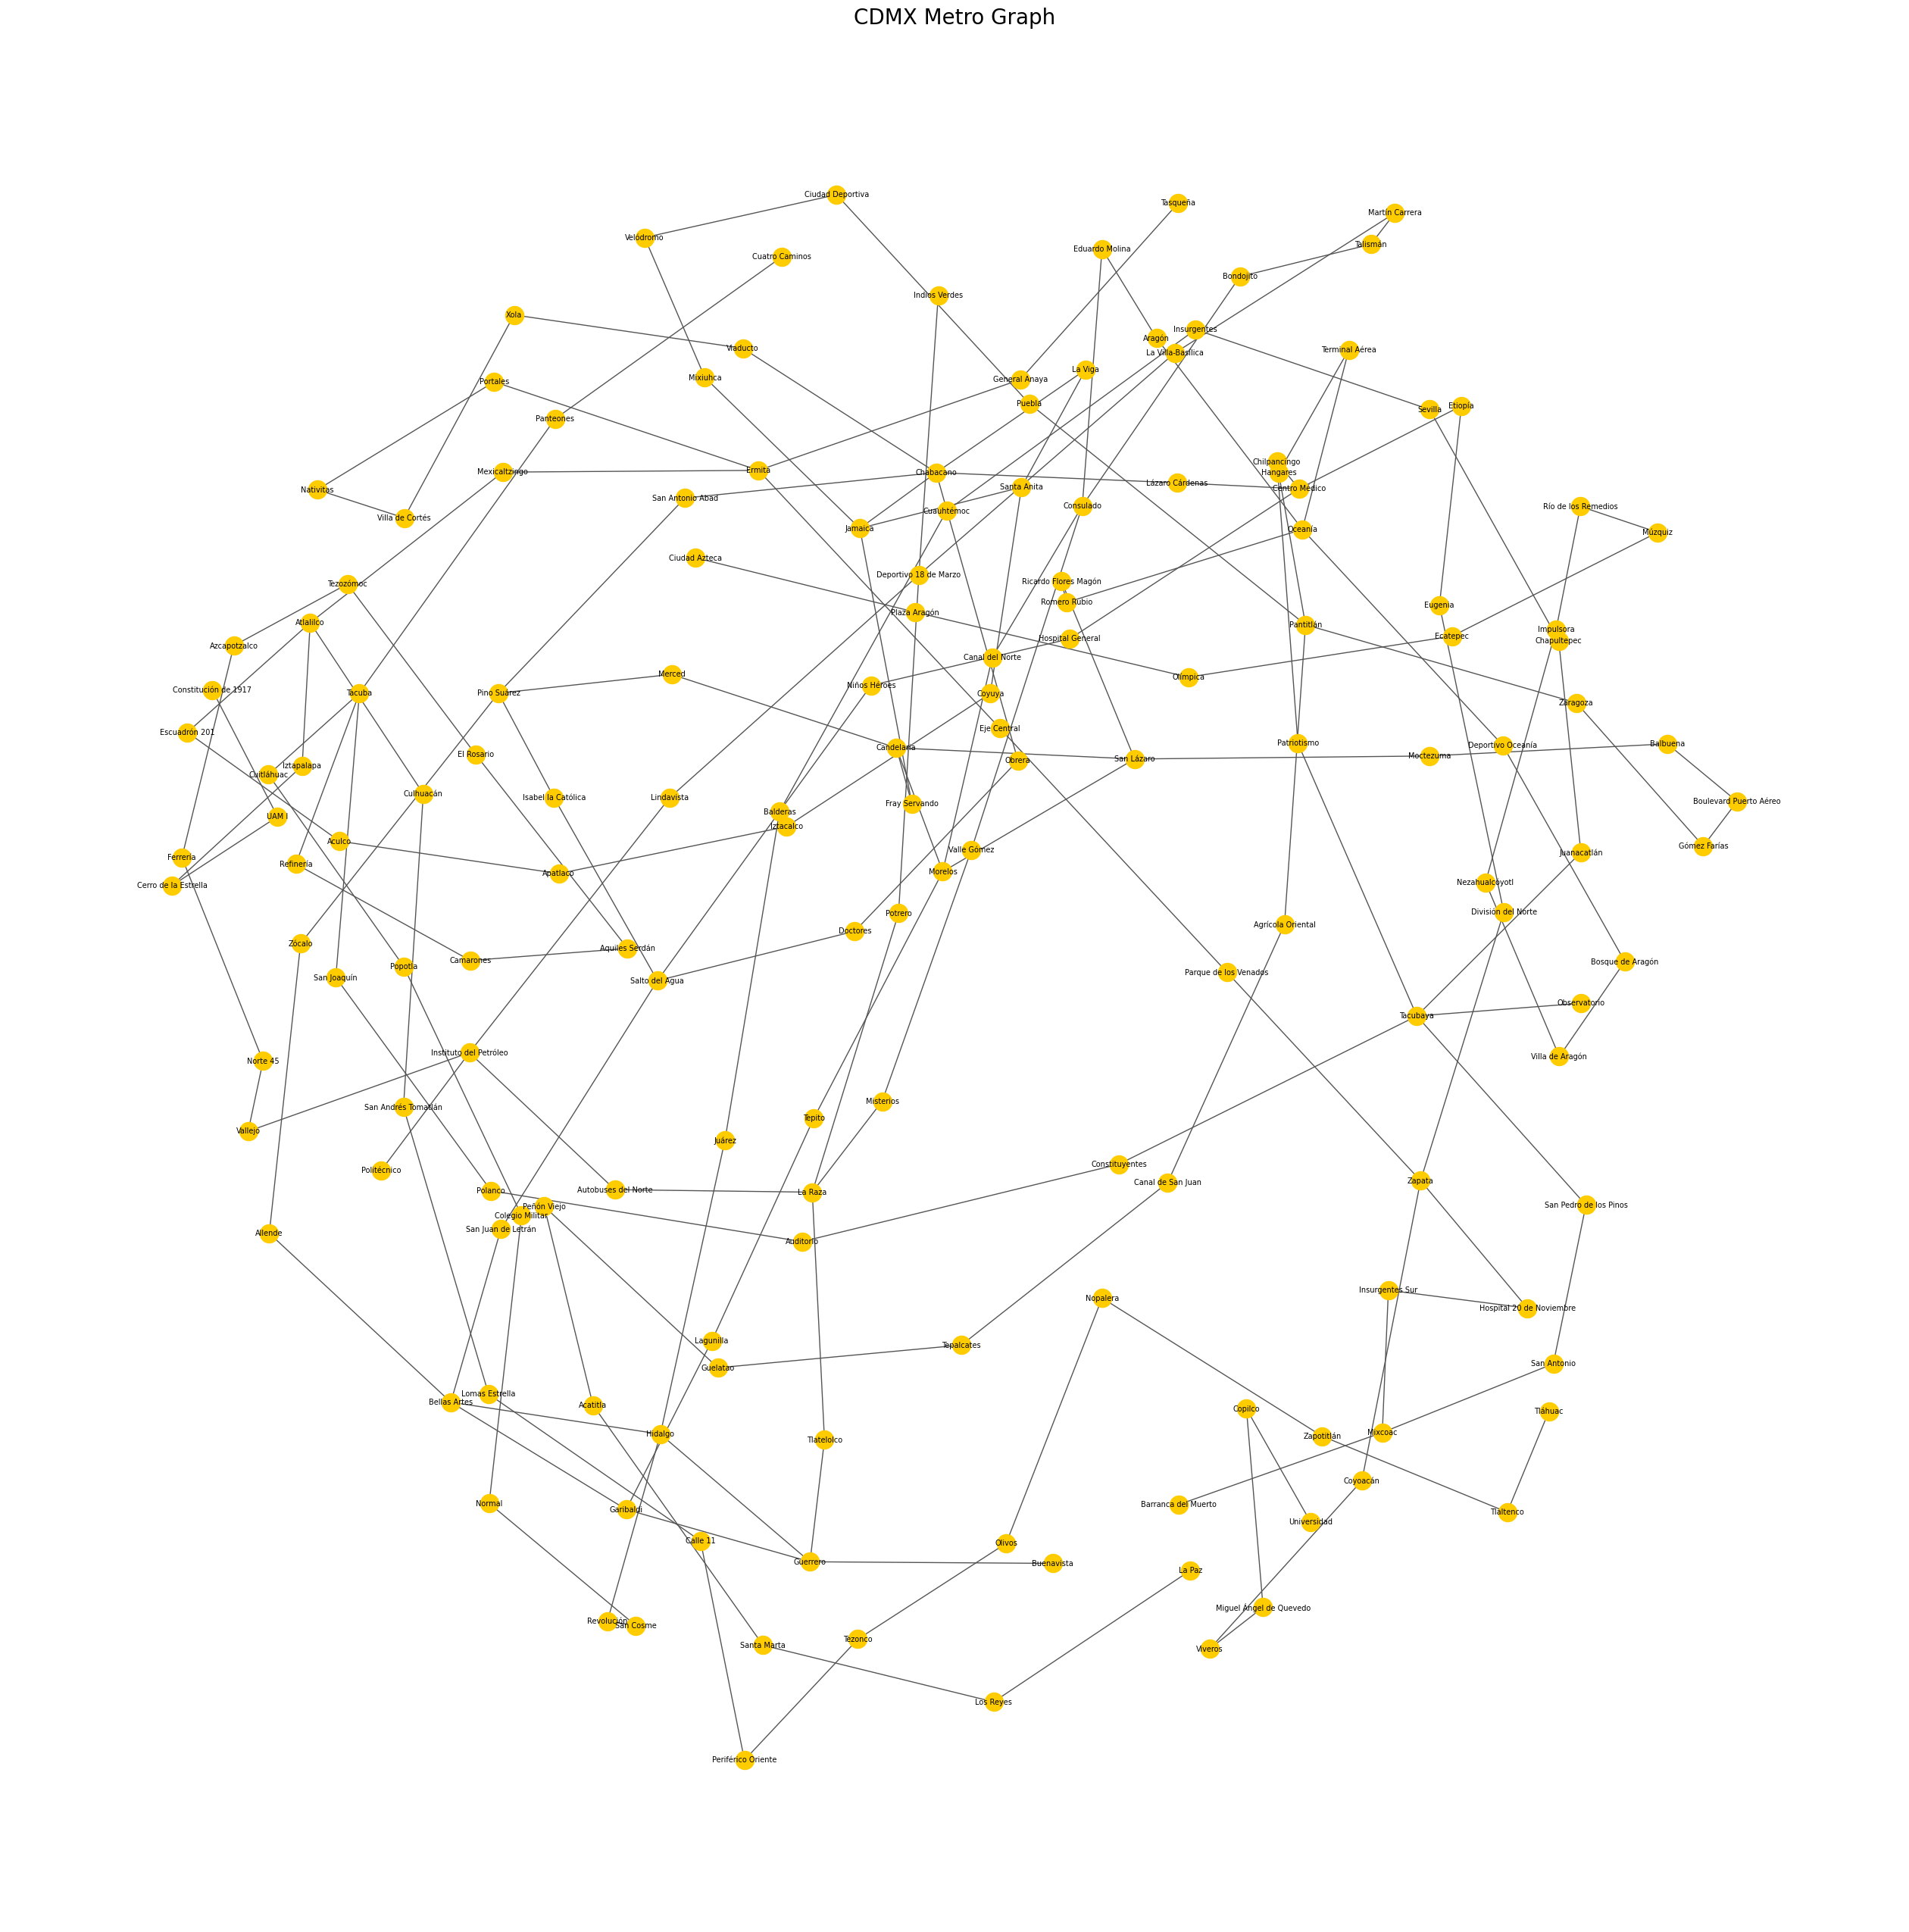

In [12]:
plt.figure(figsize=(25, 25))
pos = nx.spring_layout(G, k=0.25, iterations=50)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=300,
    font_size=7,
    node_color="#ffcc00",
    edge_color="#555555"
)

plt.title("CDMX Metro Graph", fontsize=20)
plt.savefig("output/metro_graph.png", dpi=300, bbox_inches="tight")

#plt.show()


## DFS Search Example: CDMX Metro

In [14]:
problem = GraphProblem("Vallejo", "Canal de San Juan", metro_graph)
node = depth_first_graph_search(problem)
node.path()

['Vallejo',
 'Instituto del Petróleo',
 'Lindavista',
 'Deportivo 18 de Marzo',
 'La Villa-Basílica',
 'Martín Carrera',
 'Talismán',
 'Bondojito',
 'Consulado',
 'Eduardo Molina',
 'Aragón',
 'Oceanía',
 'Romero Rubio',
 'Ricardo Flores Magón',
 'San Lázaro',
 'Morelos',
 'Tepito',
 'Lagunilla',
 'Garibaldi',
 'Guerrero',
 'Hidalgo',
 'Juárez',
 'Balderas',
 'Niños Héroes',
 'Hospital General',
 'Centro Médico',
 'Lázaro Cárdenas',
 'Chabacano',
 'Jamaica',
 'Mixiuhca',
 'Velódromo',
 'Ciudad Deportiva',
 'Puebla',
 'Pantitlán',
 'Agrícola Oriental',
 'Canal de San Juan']

In [15]:
node = breadth_first_graph_search(problem)
node.path()

['Vallejo',
 'Instituto del Petróleo',
 'Autobuses del Norte',
 'La Raza',
 'Misterios',
 'Valle Gómez',
 'Consulado',
 'Eduardo Molina',
 'Aragón',
 'Oceanía',
 'Terminal Aérea',
 'Hangares',
 'Pantitlán',
 'Agrícola Oriental',
 'Canal de San Juan']